# SMS Spam Detection
End-to-end notebook: EDA → preprocessing → model training → evaluation.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re, string, pickle
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("Setup done.")

Setup done.


## 1. Load Data

In [12]:
df = pd.read_csv('spam.csv', encoding='latin-1')[['v1','v2']]
df.columns = ['target', 'text']
df.drop_duplicates(inplace=True)
df['target'] = df['target'].map({'ham': 0, 'spam': 1})
print(df.shape)
print(df['target'].value_counts())
df.head()

(5169, 2)
target
0    4516
1     653
Name: count, dtype: int64


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 2. EDA

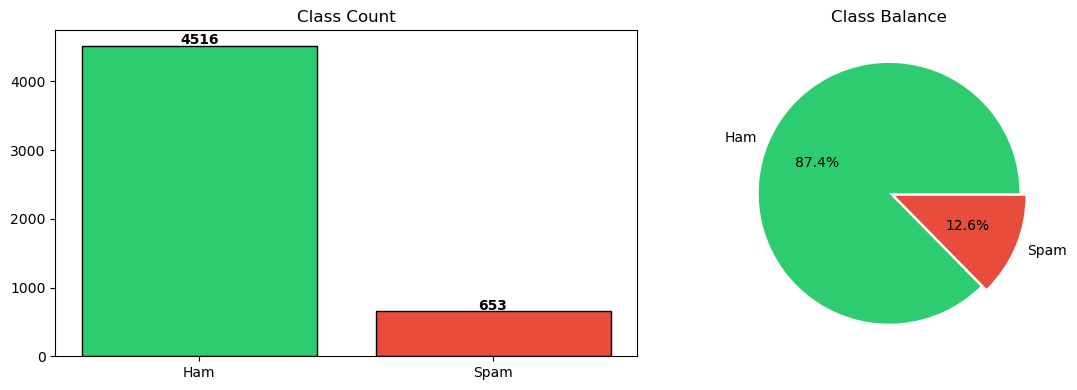

In [13]:
# Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['target'].value_counts()
axes[0].bar(['Ham','Spam'], counts.values, color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Class Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['Ham','Spam'], autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], explode=[0, 0.05])
axes[1].set_title('Class Balance')
plt.tight_layout()
plt.show()

In [14]:
# Message length
df['num_characters'] = df['text'].str.len()
df['num_words']      = df['text'].str.split().str.len()
df['num_sentences']  = df['text'].str.count(r'[.!?]+') + 1

print(df.groupby('target')[['num_characters','num_words','num_sentences']].describe().T)

target                          0           1
num_characters count  4516.000000  653.000000
               mean     70.459256  137.891271
               std      56.358207   30.137753
               min       2.000000   13.000000
               25%      34.000000  132.000000
               50%      52.000000  149.000000
               75%      90.000000  157.000000
               max     910.000000  224.000000
num_words      count  4516.000000  653.000000
               mean     14.134632   23.681470
               std      11.116240    5.967672
               min       1.000000    2.000000
               25%       7.000000   22.000000
               50%      11.000000   25.000000
               75%      18.000000   28.000000
               max     171.000000   35.000000
num_sentences  count  4516.000000  653.000000
               mean      2.692648    3.912711
               std       1.681598    1.806610
               min       1.000000    1.000000
               25%       2.000000 

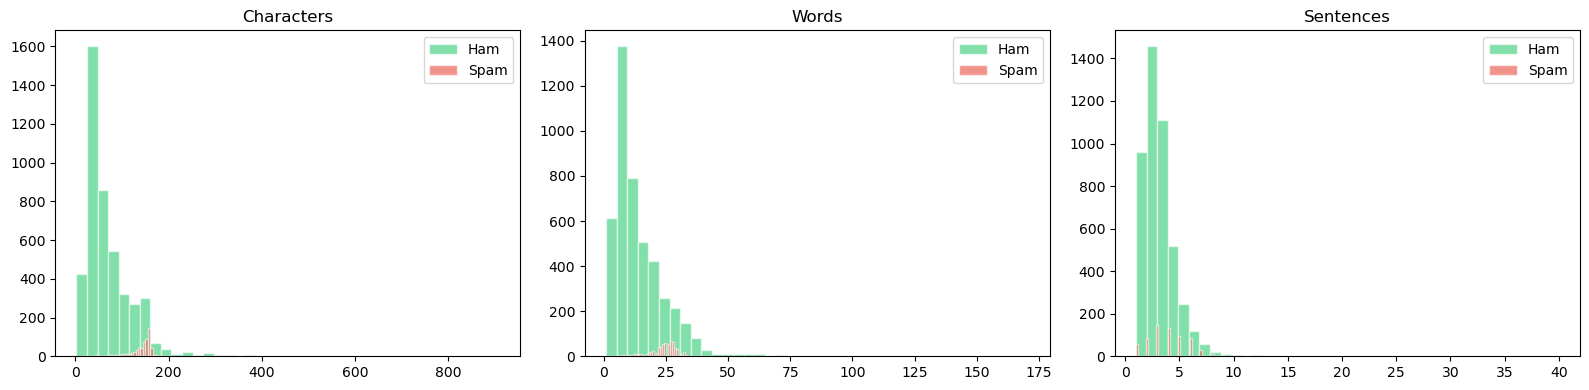

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(axes,
        ['num_characters','num_words','num_sentences'],
        ['Characters','Words','Sentences']):
    ax.hist(df[df['target']==0][col], bins=40, alpha=0.6, label='Ham',  color='#2ecc71', edgecolor='white')
    ax.hist(df[df['target']==1][col], bins=40, alpha=0.6, label='Spam', color='#e74c3c', edgecolor='white')
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [16]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', 'url', text)          # URLs → token
    text = re.sub(r'\b\d{7,}\b', 'phonenumber', text)      # phones → token
    text = re.sub(r'[£$€]\d+', 'currency', text)            # currency → token
    text = re.sub(r'\d+', '', text)                          # strip remaining digits
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [ps.stem(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['transformed_text'] = df['text'].apply(transform_text)
df[['text','transformed_text']].head(3)

,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...


## 4. Train Model

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    df['transformed_text'], df['target'],
    test_size=0.2, random_state=2, stratify=df['target']
)

# TF-IDF with bigrams (key improvement over unigram-only baseline)
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# MultinomialNB with tuned alpha
model = MultinomialNB(alpha=0.2)
model.fit(X_train_tfidf, y_train)
print("Training complete.")

Training complete.


## 5. Evaluate

In [18]:
y_pred = model.predict(X_test_tfidf)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

Accuracy : 0.9865
Precision: 0.9756

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.98      0.92      0.94       131

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



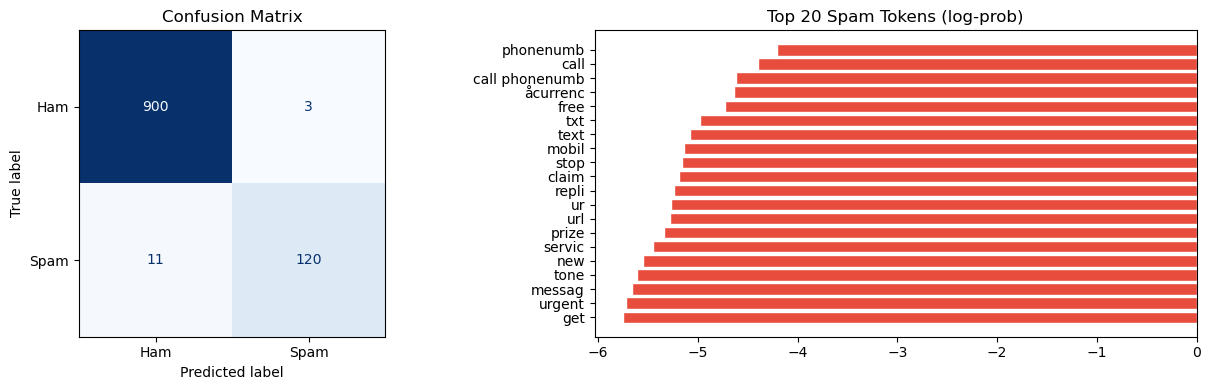

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Ham','Spam']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Top spam tokens by NB log-probability
feature_names = tfidf.get_feature_names_out()
spam_logprob  = model.feature_log_prob_[1]
top_idx = spam_logprob.argsort()[-20:][::-1]
axes[1].barh([feature_names[i] for i in top_idx][::-1],
             spam_logprob[top_idx][::-1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 20 Spam Tokens (log-prob)')
plt.tight_layout()
plt.show()

## 6. Save Artefacts

In [20]:
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(model, open('model.pkl', 'wb'))
print("Saved vectorizer.pkl and model.pkl")

Saved vectorizer.pkl and model.pkl
